In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
df=pd.read_csv("retail_store_inventory.csv")

df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [20]:
#handling missing ,duplicate value and check correct values
df.isnull().sum()
df.duplicated().sum()
df["Demand Forecast"]=df["Demand Forecast"].apply(lambda x:max(x,0))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

In [21]:
#feature engneering
df["Date"]=pd.to_datetime(df["Date"])

df["Year"]=df["Date"].dt.year
df["Quarter"]=df["Date"].dt.quarter
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df["Day"]=df['Date'].dt.day

df['Weekday'] = df['Date'].dt.day_name()
df["Is_Weekend"]=df["Date"].dt.weekday.apply(lambda x:1 if x>=5 else 0)
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [22]:
def Season(month):
  if month in [12,1,2]:
    return 'Spring'
  elif month in [3,4,5]:
    return 'Winter'
  elif month in [6,7,8]:
    return 'Autumn'
  else:
    return 'Summer'
  
df["Season"]=df['Month'].apply(Season)
df["Season"].sample(5)

52252    Autumn
61679    Summer
57080    Autumn
13303    Winter
18716    Autumn
Name: Season, dtype: object

In [23]:
#lagging feature to capute past behaviour and to predict future
df_original=df.copy()
df = df_original.copy()  # use your original dataset
df=df.sort_values(["Store ID","Product ID","Date"])


df["Sales_lag_1"]=df.groupby(["Store ID","Product ID"])['Units Sold'].shift(1)
df["Sales_lag_7"]=df.groupby(["Store ID","Product ID"])["Units Sold"].shift(7)
df["Sales_lag_30"]=df.groupby(["Store ID","Product ID"])["Units Sold"].shift(30)

df['Rolling_mean_7'] = df['Units Sold'].rolling(window=7).mean()
df['Rolling_std_7'] = df['Units Sold'].rolling(window=7).std()
df.fillna(0, inplace=True)
df.info()





<class 'pandas.core.frame.DataFrame'>
Index: 73100 entries, 0 to 73099
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       


In [24]:
#input features and target
target="Units Sold"
input_features=["Sales_lag_1","Sales_lag_7","Sales_lag_30",
                "Rolling_mean_7","Rolling_std_7",
                "Price","Discount",
                "Holiday/Promotion","Competitor Pricing",
                "Month","Is_Weekend"]

x=df[input_features]
y=df[target]
print(x.shape)
y.shape
df["Date"].min(),df["Date"].max()


(73100, 11)


(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-01-01 00:00:00'))

In [25]:
#split the dataset to test and traing dataset based on Date
split_date='2023-10-01'
train=df[df["Date"]<=split_date]
test=df[df["Date"]>'2023-10-01']
X_train=train[input_features]
Y_train=train[target]

X_test=test[input_features]
Y_test=test[target]
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(63900, 11)
(63900,)
(9200, 11)
(9200,)


In [26]:
#Train the model with linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
model=LinearRegression()
model.fit(X_train,Y_train)
print("Weights:",model.coef_)
print("Biases:",model.intercept_)

Weights: [-0.16666977  0.00182167 -0.00678779  1.16680092  0.0090541  -0.08038937
  0.04313478 -0.36478692  0.08535804 -0.00993498 -0.79517467]
Biases: -0.5405595589543282


In [27]:
#prediction on test data
Y_pred=model.predict(X_test)

mean_abs_err=mean_absolute_error(Y_test,Y_pred)
mean_squ_err=mean_squared_error(Y_test,Y_pred)
rmae=np.sqrt(mean_squ_err)

mask=Y_test!=0
mape=np.mean(np.abs((Y_test[mask]-Y_pred[mask])/Y_test[mask]))*100

print("mean absolute error:",mean_abs_err)
print("mean square error:",mean_squ_err)
print("root mean square error:",rmae)
print("mean absolute percentage error:",mape)


mean absolute error: 79.60628420877417
mean square error: 9789.851349273808
root mean square error: 98.94367766195982
mean absolute percentage error: 294.04831643385245


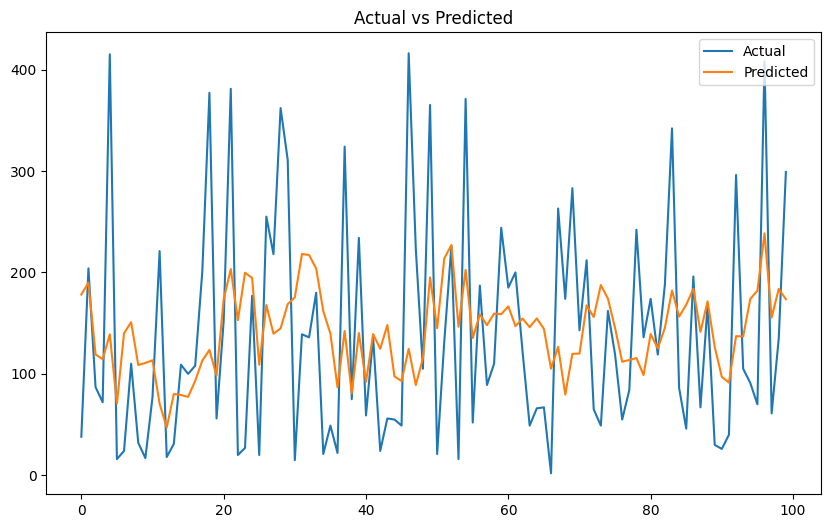

In [29]:
#visualization on predictions
plt.figure(figsize=(10,6))
plt.plot(Y_test[:100].reset_index(drop=True),label="Actual")
plt.plot(Y_pred[:100],label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()